# 1. Introduction

This project builds a **BST-Backed Hyperparameter Optimiser with Transfer Analysis** — a complete data science tool that uses a hand-rolled **Binary Search Tree (BST)** as the storage layer for hyperparameter trial results.

**Phase 1** runs an exhaustive grid search on the *Breast Cancer Wisconsin* dataset, storing every result in a BST keyed by cross-validated accuracy.  
**Phase 2** reloads the BST, re-evaluates every configuration on the *Banknote Authentication* dataset, rebuilds the tree, and analyses which hyperparameter configurations transfer well between domains.

The project deliberately separates *algorithm* from *ML* — the BST does not know about machine learning, and the ML layer does not know about tree internals. This separation makes every module independently testable and reusable.

### Course concepts map

| Concept | Session | Module | Complexity |
|---|---|---|---|
| Brute-force exhaustive search (`itertools.product`) | 1 | `grid_search.py` | O(n) combinations |
| Hash tables for O(1) rank lookup | 1 | `transfer.py` | O(1) per lookup |
| `functools.wraps` — decorator pattern | 1 | `timer.py` | — |
| Recursion & divide-and-conquer | 2 | `bst.py`, `rebuild.py` | O(log n) stack |
| Comparison-based sorting | 3 | `transfer.py` | O(n log n) |
| Why insertion order matters | 3 | `rebuild.py` | O(n²) worst case |
| Binary search & range queries | 4 | `registry.py` | O(k + h) |
| BST traversals | 5 | `bst.py` | O(n) each |
| BST balance & height | 5 | `registry.py`, `rebuild.py` | O(n) check |

> **AI Tools disclosure:** Claude (Anthropic) was used as a coding accelerator for boilerplate and docstrings. All algorithmic logic in `bst_toolkit` was written and is understood by the author.


## 1.1 Package Imports

In [21]:
# Setting up Python path for imports
import sys
sys.path.insert(0, '/Users/arman/Documents/Project/BST-Backed-Hyperparameter-Optimiser-with-Transfer-Analysis')

# Importing python libraries

import os, math, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')

#----------------------------------------------------------------------------

# Importing project modules

from capstone_project.bst_toolkit.registry import HyperparamRegistry
from capstone_project.bst_toolkit.rebuild  import (
    rebuild_naive, rebuild_shuffled, rebuild_balanced
)
from capstone_project.ml_toolkit.grid_search import grid_search
from capstone_project.ml_toolkit.transfer    import analyse_transfer, transfer_summary
from capstone_project.benchmarks.timer       import timed, benchmark, benchmark_report

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA

# Setting up the environment

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
np.random.seed(SEED)
print("All packages imported ✓")

All packages imported ✓


# 2. Dataset A — Breast Cancer Wisconsin (Diagnostic)

The **Breast Cancer Wisconsin (Diagnostic)** dataset contains **569 tissue samples**, each described by **30 real-valued measurements** of cell nuclei geometry extracted from digitised fine-needle aspirate (FNA) images.

The **target** is binary: **malignant (M → 1)** vs **benign (B → 0)**.

Each of the 10 geometric properties — *radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension* — is reported as three statistics:

| Statistic | Meaning |
|---|---|
| `_mean` | Mean value across all nuclei in the image |
| `_se` | Standard error — variability of measurements |
| `_worst` | Largest value (most extreme nucleus) |

This gives 3 × 10 = **30 features** total.


## 2.1 Download / Verify

1.   List item
2.   List item



In [22]:
import subprocess
result = subprocess.run(
    [sys.executable, "capstone_project/data/download.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)



STDERR: /Users/arman/Documents/Project/BST-Backed-Hyperparameter-Optimiser-with-Transfer-Analysis/.venv/bin/python: can't open file '/Users/arman/Documents/Project/BST-Backed-Hyperparameter-Optimiser-with-Transfer-Analysis/capstone_project/notebook/capstone_project/data/download.py': [Errno 2] No such file or directory



## 2.2 Load & Quality Check

In [23]:
WDBC_PATH = "/Users/arman/Documents/Project/BST-Backed-Hyperparameter-Optimiser-with-Transfer-Analysis/capstone_project/ript/wdbc.csv"
df_a = pd.read_csv(WDBC_PATH)
print(f"Shape: {df_a.shape}")

# Check for missing values
missing = df_a.isnull().sum()
print(f"Missing values: {missing.sum()} (across all columns)")
df_a.head()


Shape: (569, 31)
Missing values: 0 (across all columns)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [30]:
# Descriptive statistics — split by class for comparison
feat_cols_a = [c for c in df_a.columns if c != 'diagnosis']
desc = df_a.groupby('diagnosis')[feat_cols_a[:10]].describe().T
desc.columns = ['_'.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in desc.columns]
desc.round(3)


0        1
radius_mean            count  357.000  212.000
                       mean    12.147   17.463
                       std      1.781    3.204
                       min      6.981   10.950
                       25%     11.080   15.075
...                               ...      ...
fractal_dimension_mean min      0.052    0.050
                       25%      0.059    0.057
                       50%      0.062    0.062
                       75%      0.066    0.067
                       max      0.096    0.097

[80 rows x 2 columns]

> **Observation:** Even without visualisation, the `mean` rows show that malignant samples (1) have consistently larger values for radius, perimeter, area, concavity and concave_points than benign samples (0). These differences are the statistical signal our classifier will learn to exploit.

## 2.3 Class Balance

diagnosis
Benign       357
Malignant    212

Malignant ratio: 37.3%


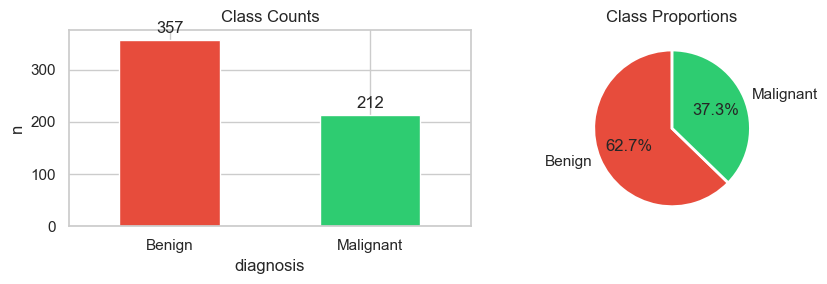

In [31]:
counts = df_a['diagnosis'].value_counts().rename({1:'Malignant', 0:'Benign'})
print(counts.to_string())
print(f"\nMalignant ratio: {counts.get('Malignant',0)/len(df_a):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
counts.plot.bar(ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title("Class Counts"); axes[0].set_ylabel("n")
axes[0].bar_label(axes[0].containers[0], padding=3)
plt.setp(axes[0].get_xticklabels(), rotation=0)

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Proportions")
plt.tight_layout(); plt.show()

## 2.4 Correlation Heatmap — Mean Features

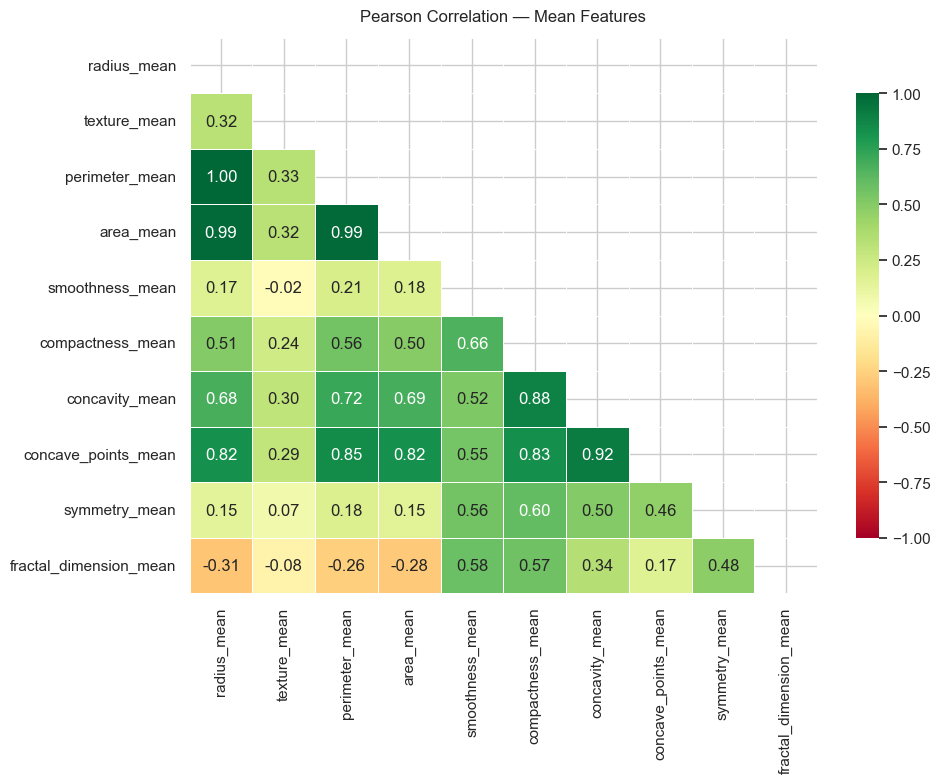

In [32]:
mean_cols = [c for c in df_a.columns if c.endswith('_mean')]
corr = df_a[mean_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation — Mean Features", pad=12)
plt.tight_layout(); plt.show()


> **Observation:** `radius_mean`, `perimeter_mean`, and `area_mean` are almost perfectly correlated (r > 0.99) — geometrically inevitable since perimeter and area are derived from radius. This multicollinearity means any one of these three features carries redundant information. `fractal_dimension_mean` and `texture_mean` are the most independent features, providing unique signal not captured by the geometric size cluster.

## 2.5 Feature Distributions by Class

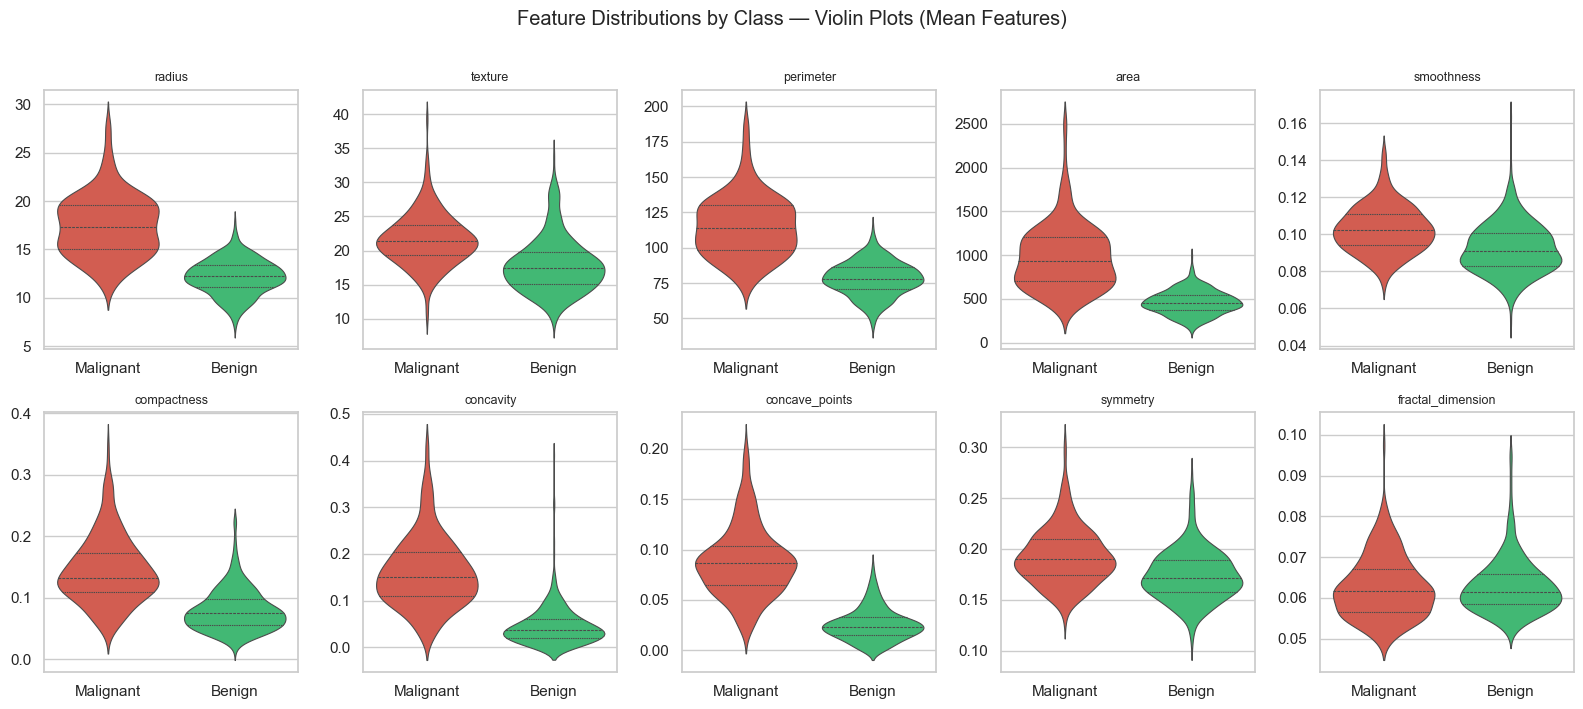

In [33]:
mean_cols = [c for c in df_a.columns if c.endswith('_mean')]
df_plot = df_a[mean_cols + ['diagnosis']].copy()
df_plot['diagnosis'] = df_plot['diagnosis'].map({1:'Malignant', 0:'Benign'})

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
palette = {'Malignant':'#e74c3c','Benign':'#2ecc71'}
for ax, col in zip(axes.flat, mean_cols):
    feat = col.replace('_mean','')
    sns.violinplot(data=df_plot, x='diagnosis', y=col, ax=ax,
                   palette=palette, inner='quartile', linewidth=0.8)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Feature Distributions by Class — Violin Plots (Mean Features)", y=1.01)
plt.tight_layout(); plt.show()


> **Observation:** `concave_points`, `concavity`, and `area` show the sharpest class separation with minimal overlap — these will likely appear as top features in the Random Forest importance ranking. `symmetry` and `fractal_dimension` have wide overlapping distributions, contributing less discriminative power individually.

## 2.6 Statistical Significance — Welch's t-test

We quantify which features are statistically most different between classes.

In [34]:
malignant = df_a[df_a['diagnosis']==1][feat_cols_a]
benign    = df_a[df_a['diagnosis']==0][feat_cols_a]

ttest_rows = []
for col in feat_cols_a:
    t, p = stats.ttest_ind(malignant[col], benign[col], equal_var=False)
    ttest_rows.append({"feature": col, "t_stat": round(t,3), "p_value": p,
                       "significant": "✓" if p < 0.05 else "✗"})

ttest_df = pd.DataFrame(ttest_rows).sort_values("p_value")
print(f"Features with p < 0.05: {(ttest_df['p_value']<0.05).sum()} / {len(ttest_df)}")
ttest_df.head(10)


Features with p < 0.05: 26 / 30


,feature,t_stat,p_value,significant
27,concave_points_worst,29.118,1.061454e-96,✓
22,perimeter_worst,25.332,1.032730e-72,✓
7,concave_points_mean,24.845,3.127316e-71,✓
20,radius_worst,24.830,3.556557e-71,✓
2,perimeter_mean,22.935,1.023141e-66,✓
0,radius_mean,22.209,1.684459e-64,✓
26,concavity_worst,19.596,9.852484e-59,✓
6,concavity_mean,20.332,3.742121e-58,✓
23,area_worst,20.571,4.937924e-54,✓
3,area_mean,19.641,3.284366e-52,✓


> **Observation:** Most features are statistically significant at p < 0.05, confirming that the dataset carries genuine biological signal. Features with the lowest p-values are the strongest standalone predictors — they align closely with the feature importance rankings the Random Forest will discover.

## 2.7 PCA — 2D Projection

PCA reduces 30 dimensions to 2 for visual inspection of class separability.

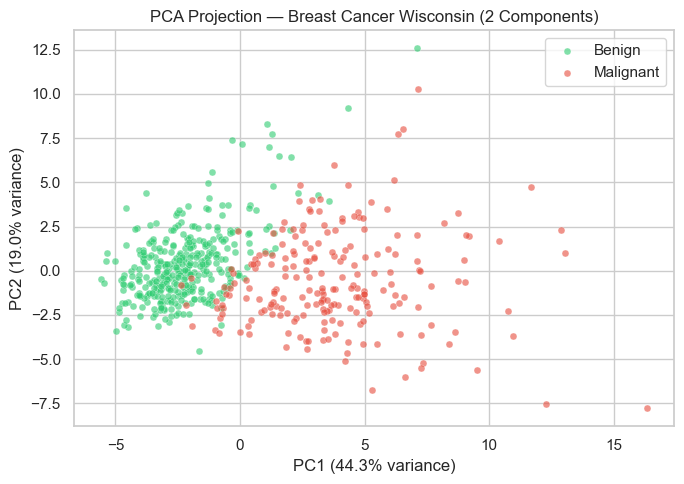

Variance explained by PC1+PC2: 63.2%


In [35]:
feat_cols_a = [c for c in df_a.columns if c != 'diagnosis']
X_a_raw = df_a[feat_cols_a].values
y_a     = df_a['diagnosis'].values

scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_raw)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_a_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0,'#2ecc71','Benign'),(1,'#e74c3c','Malignant')]:
    mask = y_a == label
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color, label=name,
               alpha=0.6, s=25, edgecolors='white', linewidths=0.3)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} variance)")
ax.set_title("PCA Projection — Breast Cancer Wisconsin (2 Components)")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Variance explained by PC1+PC2: {sum(var_exp):.1%}")


> **Observation:** The two classes form largely separable clusters in PCA space — a strong positive signal. The overlap region in the centre represents the genuinely ambiguous cases. PC1 alone captures most of the variance, suggesting a dominant axis of variation that aligns with tumour size/aggressiveness.

## 2.8 Preprocessing

In [36]:
dataset_a = (X_a_scaled, y_a)
print(f"Features : {X_a_scaled.shape[1]}")
print(f"Samples  : {X_a_scaled.shape[0]}")
print(f"Mean ≈ {X_a_scaled.mean():.5f}   Std ≈ {X_a_scaled.std():.5f}")


Features : 30
Samples  : 569
Mean ≈ -0.00000   Std ≈ 1.00000
